In [1]:
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
import numpy as np
plt.style.use('ggplot')

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [2]:
# df_raw=pd.read_csv('spotify_dataset.csv', sep=',', engine='python', index_col=0)
df_raw = pd.read_csv("hf://datasets/maharshipandya/spotify-tracks-dataset/dataset.csv", index_col=0)
df_raw

c:\Users\igory\AppData\Local\Programs\Python\Python310\lib\site-packages\requests\__init__.py:102: RequestsDependencyWarning: urllib3 (1.25.11) or chardet (5.1.0)/charset_normalizer (2.0.11) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({})/charset_normalizer ({}) doesn't match a supported "


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


# Data Undertanding:

In [3]:
print("Dataset shape:", df_raw.shape)
print("Dataset Information:", df_raw.info)

Dataset shape: (114000, 20)
Dataset Information: <bound method DataFrame.info of                       track_id                 artists  \
0       5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1       4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2       1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3       6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4       5vjLSffimiIP26QG5WcN2K        Chord Overstreet   
...                        ...                     ...   
113995  2C3TZjDRiAzdyViavDJ217           Rainy Lullaby   
113996  1hIz5L4IB9hN3WRYPOCGPw           Rainy Lullaby   
113997  6x8ZfSoqDjuNa5SVP5QjvX           Cesária Evora   
113998  2e6sXL2bYv4bSz6VTdnfLs        Michael W. Smith   
113999  2hETkH7cOfqmz3LqZDHZf5           Cesária Evora   

                                               album_name  \
0                                                  Comedy   
1                                        Ghost (Acoustic)   
2                                      

In [4]:
df_raw.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [5]:
df_raw['duration_ms'].unique()

array([230666, 149610, 210826, ..., 250629, 312566, 271466], dtype=int64)

In [6]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

In [7]:
df_raw.isnull().sum()

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

# Column Description

- **track_id**: The Spotify ID for the track.

- **artists**: The names of the artists who performed the track. If there is more than one artist, their names are separated by a `;`.

- **album_name**: The name of the album in which the track appears.

- **track_name**: The name of the track.

- **popularity**: A value between **0 and 100**, where **100 represents the most popular tracks**. Popularity is calculated algorithmically and is based primarily on the total number of plays and how recent those plays are. Generally, songs that are played frequently now will have higher popularity than songs that were popular in the past. Duplicate tracks, such as the same song appearing on both a single and an album, are rated independently.

- **duration_ms**: The duration of the track in milliseconds.

- **explicit**: Indicates whether the track contains explicit lyrics:
  - `true` — explicit lyrics are present.
  - `false` — no explicit lyrics or the information is unknown.

- **danceability**: Describes how suitable a track is for dancing based on musical elements such as tempo, rhythm stability, beat strength, and overall regularity. Values range from `0.0` (least danceable) to `1.0` (most danceable).

- **energy**: A measure of intensity and activity ranging from `0.0` to `1.0`. High-energy tracks typically feel fast, loud, and intense, while low-energy tracks tend to be calmer and softer.

- **key**: The musical key of the track. Integers correspond to pitches using standard Pitch Class notation:
  - `0 = C`
  - `1 = C♯/D♭`
  - `2 = D`
  - `...`
  - `11 = B`
  - `-1` indicates that no key was detected.

- **loudness**: The overall loudness of a track, measured in decibels (`dB`).

- **mode**: Indicates the modality of the track:
  - `1` — major.
  - `0` — minor.

- **speechiness**: Detects the presence of spoken words in a track.
  - Values above `0.66` typically indicate tracks consisting primarily of spoken words.
  - Values between `0.33` and `0.66` may indicate a combination of music and speech, such as rap.
  - Values below `0.33` most likely represent music with little or no spoken content.

- **acousticness**: A confidence measure ranging from `0.0` to `1.0` that indicates whether a track is acoustic. A value of `1.0` represents high confidence that the track is acoustic.

- **instrumentalness**: Predicts whether a track contains no vocals. Values closer to `1.0` indicate a higher probability that the track is instrumental.

- **liveness**: Detects the presence of an audience in the recording. Higher values indicate a greater probability that the track was performed live. Values above `0.8` provide a strong indication of a live performance.

- **valence**: A measure ranging from `0.0` to `1.0` that describes the musical positiveness conveyed by a track. Higher values indicate more positive, happy, or cheerful sounds, while lower values indicate more negative, sad, or angry sounds.

- **tempo**: The estimated tempo of the track, measured in beats per minute (`BPM`).

- **time_signature**: The estimated time signature of the track. Values typically range from `3` to `7`, representing time signatures such as `3/4`, `4/4`, `5/4`, `6/4`, and `7/4`.

- **track_genre**: The genre to which the track belongs.

In [8]:
df_raw.columns


Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

In [9]:
df = df_raw.copy()
df['duration_minutes'] = df['duration_ms'] / 1000 / 60
df['duration_seconds'] = df['duration_ms'] / 1000
components = pd.to_timedelta(df['duration_ms'], unit='ms').dt.components
df['duration'] = (
    components['minutes'].astype(str).str.zfill(2) + ":" + 
    components['seconds'].astype(str).str.zfill(2)
)

In [10]:
df

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_minutes,duration_seconds,duration
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic,3.844433,230.666,03:50
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic,2.493500,149.610,02:29
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic,3.513767,210.826,03:30
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic,3.365550,201.933,03:21
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic,3.314217,198.853,03:18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,...,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music,6.416650,384.999,06:24
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,...,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music,6.416667,385.000,06:25
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,...,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music,4.524433,271.466,04:31
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,...,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music,4.731550,283.893,04:43


# Explicit songs analysis:

In [11]:
y = df_raw['explicit'].value_counts()

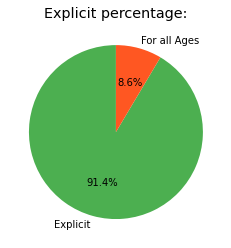

In [12]:
plt.pie(y, 
        autopct="%1.1f%%",  # Displays percentages on the wedges
        startangle=90,  # Rotates the start of the pie for a cleaner look
        colors=["#4CAF50", "#FF5722"],  # Custom colours (Optional: Green for Explicit, Red for not Explicit)
        labels=["Explicit", "For all Ages"],  # Explicitly label the slices
    )
plt.title("Explicit percentage:")
plt.ylabel("")  # Removes the default column name label on the side

plt.show()

From this diagram we can see that over 90% of the songs being explicit and only 8.6% of all songs can be played around childrens. In that case we can clearly see that main audience of Spotify services mainly adult.

What makes explicit songs explicit? \
Let's do the research about Explicit parameter depended on continuos features:

In [13]:
continuous_features = ['loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

C:\Users\igory\AppData\Local\Temp\ipykernel_28344\3756593938.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='explicit', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\igory\AppData\Local\Temp\ipykernel_28344\3756593938.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='explicit', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\igory\AppData\Local\Temp\ipykernel_28344\3756593938.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='explicit', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\igory\AppData\Local\Temp\

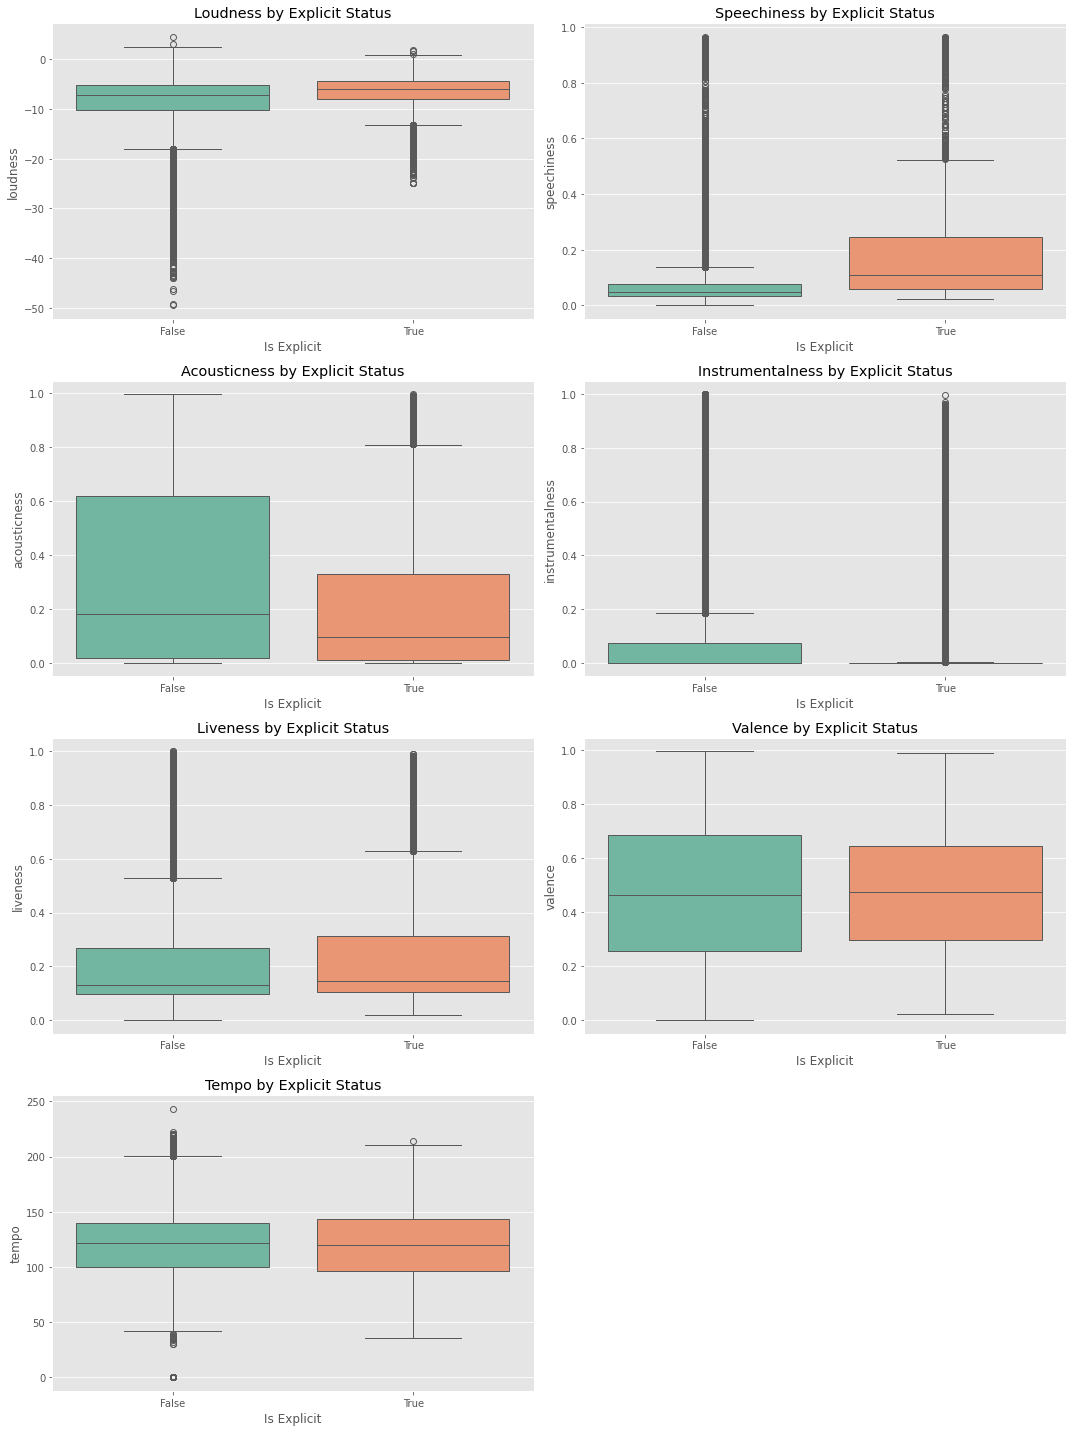

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    # Creating a boxplot to compare medians and dispersion
    sns.boxplot(x='explicit', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(col.capitalize() + ' by Explicit Status')
    axes[i].set_xlabel('Is Explicit')
    axes[i].set_ylabel(col)

# We delete the last (eighth) empty graph, since there are 7 features
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

From this boxplots we can see that the most interesting features that affect explicit status is **speechiness**, **instrumentalness**, **acousticness** and **loudness** \
But let's continue our research...

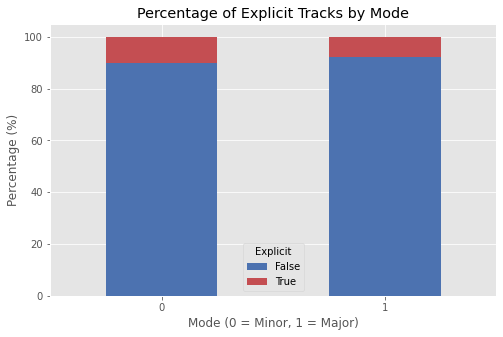

In [ ]:
# 2. Analysis of the categorical feature 'mode'
mode_explicit = pd.crosstab(df['mode'], df['explicit'], normalize='index') * 100
mode_explicit.plot(kind='bar', stacked=True, color=['#4c72b0', '#c44e52'], figsize=(8, 5))
plt.title('Percentage of Explicit Tracks by Mode')
plt.xlabel('Mode (0 = Minor, 1 = Major)')
plt.ylabel('Percentage (%)')
plt.legend(title='Explicit')
plt.xticks(rotation=0)
plt.show()

From this graph we could not see much difference between both explicit and non-explicit factors by **Mode** \
Let's continue...

In [ ]:
# 3. Numerical analysis: average values
print("Mean values grouped by Explicit status:")
print(df.groupby('explicit')[continuous_features].mean().T)

Mean values grouped by Explicit status:
explicit               False        True
loudness           -8.425947   -6.472891
speechiness         0.074696    0.191139
acousticness        0.324508    0.212247
instrumentalness    0.165837    0.051366
liveness            0.211658    0.233819
valence             0.474336    0.471202
tempo             122.173653  121.871713


Based on the calculated averages, we can draw several key conclusions about the nature of "explicit" tracks. \ 
The features fall into three distinct groups based on the degree of influence: 
1. Strong correlation (Primary explicit markers): 
   - **speechiness**: This metric is 2.5 times higher for explicit tracks (0.191 vs. 0.074). It is the most prominent marker. Such tracks contain significantly more lyrics and spoken word, which is characteristic of rap, hip-hop, and spoken-word genres. 
   - **instrumentalness**: This metric is 3 times lower for explicit tracks (0.051 vs. 0.165). The logical conclusion is that tracks containing profanity are almost never purely instrumental; they almost always feature vocals. 
   - **acousticness**: This is noticeably lower for explicit tracks (0.212 vs. 0.324). This suggests that tracks with explicit lyrics are more likely to be created using electronic or synthesized instruments rather than acoustic ones (like guitars or pianos). 
2. Moderate correlation: 
   - **loudness**: Explicit tracks are louder on average (-6.47 dB vs. -8.42 dB; remember that the scale is negative, so values ​​closer to 0 indicate greater loudness). This confirms the hypothesis that explicit content is more common in genres that are more aggressive, dynamic, and sonically "pumped up" for commercial appeal. 
   - **liveness**: The difference is slight, but the metric is marginally higher for explicit tracks (0.233 vs. 0.211). This may be due to a greater presence of "live" vocal effects or background noise. 
3. No correlation (Neutral features): 
   - **tempo**: The average tempo is virtually identical for both groups (~122 BPM). The tempo of the music is unrelated to the presence of explicit lyrics. Valence (musical positivity): The values ​​are identical (~0.47). Explicit tracks can be sad/somber or cheerful in exactly the same proportions as standard songs.

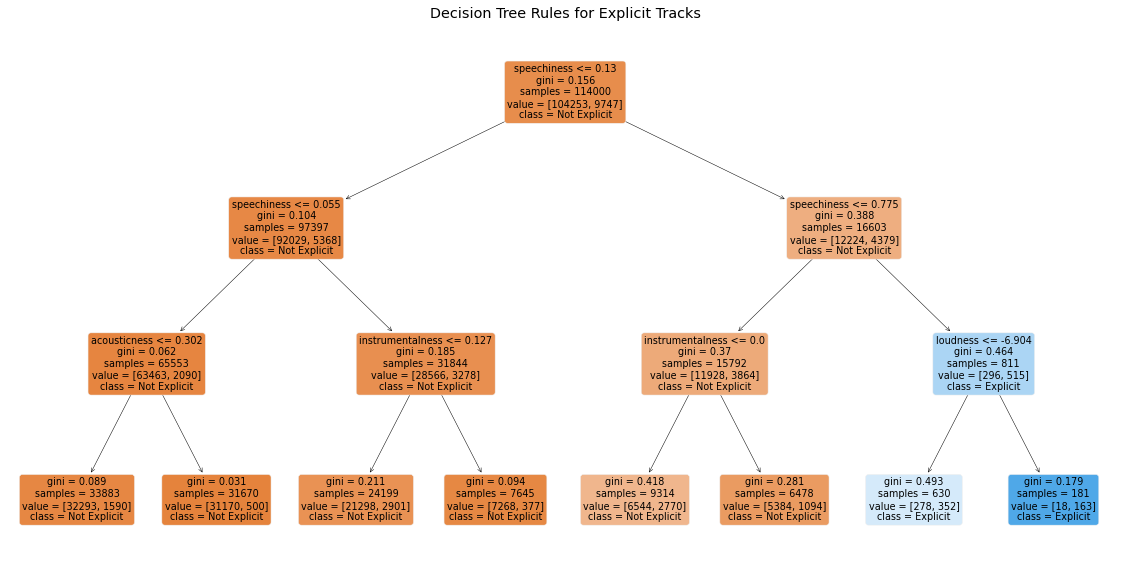

In [ ]:
# Selecting features and the target variable
features = ['loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
X = df[features]
y = df['explicit'].astype(int) # convert True/False to 1/0

# Limiting the depth to make the tree readable and clear
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X, y)

# Tree visualization
plt.figure(figsize=(20, 10))
plot_tree(tree_model, feature_names=features, class_names=['Not Explicit', 'Explicit'], filled=True, rounded=True)
plt.title("Decision Tree Rules for Explicit Tracks")
plt.show()

Based on this decision tree, we can draw very clear conclusions about the logic behind track classification—insights.\
The model confirmed our previous hypotheses and identified specific numerical thresholds:
1. The primary splitting factor (Root node): 
- `speechiness <= 0.13` — this is the tree's very first and most important rule. 
- Note that 91.4% of all tracks in the dataset (104,253 out of 114,000) are initially classified as **"Not Explicit."** 
- The model immediately splits the data: if `speechiness > 0.13` (moving to the right), the concentration of explicit tracks rises sharply. Of the 16,603 tracks in the right branch, 4,379 are explicit (about 26%, which is far higher than the dataset average). 
2. Finding "pure" explicit content (Right branch): 
- Moving right along the tree (`speechiness > 0.13`), the next key threshold is `speechiness <= 0.775`. 
- If `speechiness > 0.775` (moving to the far-right branch), we encounter tracks consisting almost entirely of spoken words (e.g., podcasts, audiobooks, or a cappella rap). Here, the model checks loudness (`loudness <= -6.904`). 
- If such a "highly spoken" track is loud (`loudness > -6.904`), we land in the far-right blue leaf node: out of 181 tracks, 163 are explicit (90%). This is the "purest" zone for explicit content in the dataset. 
3. Where there are virtually no Explicit tracks (left branch): 
- If we move to the left along the tree (speechiness <= 0.13), the majority of these tracks (at the far left) are classified as Not Explicit. 
- It is interesting to examine the checks for acousticness <= 0.302 and instrumentalness <= 0.127. The model confirms that if a track is instrumental (instrumentalness > 0.127), the probability of encountering explicit lyrics drops to a minimum (with only 377 explicit tracks out of 7,645 in the corresponding leaf node).

C:\Users\igory\AppData\Local\Temp\ipykernel_28344\1417761811.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=importance_df, palette='vlag')


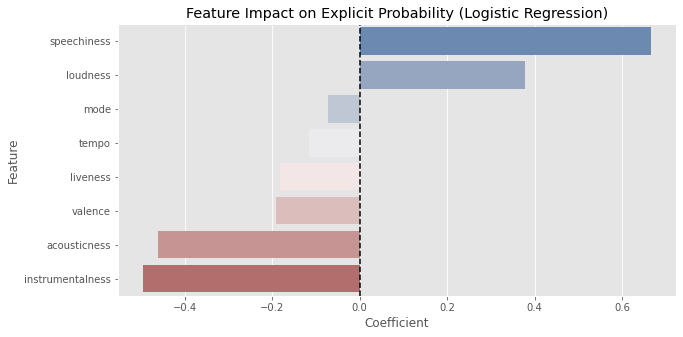

In [ ]:
# Feature scaling is essential for a valid comparison of weights.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_scaled, y)

# Create a dataframe with coefficients
importance_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

# Visualizing Importance
plt.figure(figsize=(10, 5))
sns.barplot(x='Coefficient', y='Feature', data=importance_df, palette='vlag')
plt.title('Feature Impact on Explicit Probability (Logistic Regression)')
plt.axvline(0, color='black', linestyle='--')
plt.show()

As we can see by logistic regression, the explicit factor mostly relies on **higher speechiness** and **loudness** features and **lower instrumentalness** and **valence**, which is as expected for explicit content with more words in texts and more loud and angry tones of music. \ 
Specifically, the model reveals that:
- Speechiness is the single strongest predictor (`coefficient ~0.65`), confirming that explicit tracks are heavily driven by spoken words and lyrics rather than melody alone.
- Loudness acts as a major catalyst, suggesting that non-explicit tracks tend to be quieter, while explicit content thrives in louder, high-energy productions.
- Instrumentalness and acousticness show strong negative impacts (`coefficients around -0.5`), mathematically proving that explicit tracks are rarely acoustic and almost never purely instrumental.
- A lower valence (`negative coefficient`) further highlights that explicit songs lean slightly towards more aggressive, melancholic, or serious moods rather than cheerful vibes.

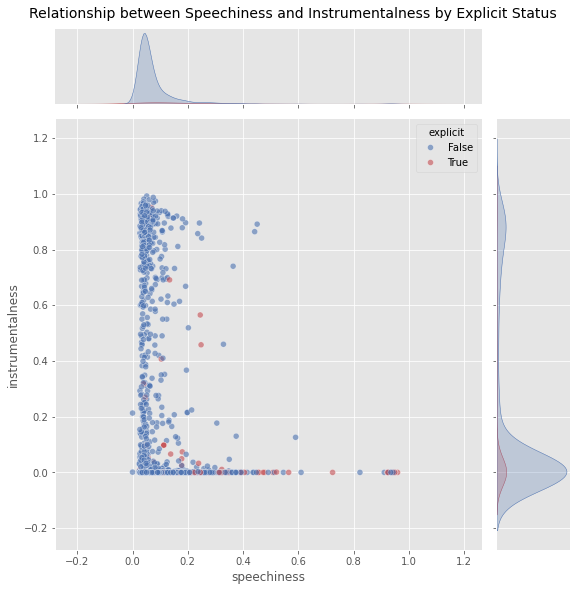

In [ ]:
# Take a random sample so that points do not overlap too much
# If the dataset is small, you can simply use df instead of df.sample(...)
df_sample = df.sample(n=min(2000, len(df)), random_state=42)

# Creating a Jointplot
g = sns.jointplot(
    data=df_sample, 
    x='speechiness', 
    y='instrumentalness', 
    hue='explicit', 
    palette={False: '#4c72b0', True: '#c44e52'}, # blue for False, red for True
    alpha=0.6,
    height=8
)

# Adding a general name
g.fig.suptitle('Relationship between Speechiness and Instrumentalness by Explicit Status', y=1.02, fontsize=14)

plt.show()

1. Confirmation of the main hypothesis: The "bottom-right corner effect." 
   - Conclusion: Virtually all red dots (`explicit=True`) are concentrated at the very bottom edge of the graph, where `instrumentalness` is exactly 0.0. 
   - Explanation: The graph clearly confirms that tracks containing explicit language require vocals. As soon as `instrumentalness` rises above the 0.1 level, the red dots disappear (with literally just a couple of isolated exceptions). 
2. EDA surprise: Anomaly in the `speechiness` distribution. 
   - Our hypothesis stated: "There will be a dense concentration of explicit tracks in the high-`speechiness` zone." However, the graph reveals a different reality. 
   - Conclusion: Tracks with high `speechiness` levels (0.4 to 1.0) are actually extremely rare in the dataset (the scatter plot is very sparse in that area), and visually, there are even more blue dots (`False`) than red ones (`True`) among them. 
   - Explanation: The region where `speechiness` > 0.5 likely consists not of rap music, but of non-musical tracks (spoken-word podcasts, audiobooks, skits, stand-up comedy). And profanity is by no means always present in such content. 
3. Where is explicit content actually hiding? Conclusion: 
   - The bulk of the red dots is clustered in the `speechiness` range of 0.05 to 0.35, with `instrumentalness` close to 0. 
   - Explanation: This specific range characterizes standard vocal music tracks (pop, rock, rap hits). There is enough lyrical content for the `speechiness` metric to detect speech, yet the track remains a musical piece rather than a monologue. 
4. Analysis of density plots (on the margins). Top graph (`speechiness`): 
   - The blue and red "hills" overlap almost completely. This means that "speechiness" on its own is not a "magic wand" that instantly distinguishes profanity from non-profanity. 
   - The graph on the right (instrumentalness) shows a massive difference. 
   - The blue curve has a long tail extending upwards (since ordinary tracks can be instrumental), whereas the red curve is a single, sharp, isolated peak right at zero.